In [1]:
from FIT_python.step_01_data_import.utils import load_raw_files
from FIT_python.config import RAW_DIR
raw_dfs = load_raw_files(RAW_DIR)
raw_dfs

{'Amur_Tiger':                  id                  species individual_id   trail sex  \
 0      Amur_Tiger_1  Panthera tigris altaica          M541  M541 A   M   
 1      Amur_Tiger_2  Panthera tigris altaica          M541  M541 A   M   
 2      Amur_Tiger_3  Panthera tigris altaica          M541  M541 A   M   
 3      Amur_Tiger_4  Panthera tigris altaica          M541  M541 A   M   
 4      Amur_Tiger_5  Panthera tigris altaica          M541  M541 A   M   
 ..              ...                      ...           ...     ...  ..   
 600  Amur_Tiger_601  Panthera tigris altaica         M1084   M1084   M   
 601  Amur_Tiger_602  Panthera tigris altaica         M1084   M1084   M   
 602  Amur_Tiger_603  Panthera tigris altaica         M1084   M1084   M   
 603  Amur_Tiger_604  Panthera tigris altaica         M1084   M1084   M   
 604  Amur_Tiger_605  Panthera tigris altaica         M1084   M1084   M   
 
            v1        v2        v3        v4        v5  ...       area1  \
 0    3.2

In [ ]:
from FIT_python.pipeline.split_wrapper import SplitWrapper

splitper = SplitWrapper()
splitper.split_all()


ImportError: cannot import name '_make_folds' from partially initialized module 'FIT_python.step_02_a_splitting_train_test.utils' (most likely due to a circular import) (C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\step_02_a_splitting_train_test\utils.py)

In [ ]:
from FIT_python.step_02_b_summary_datasets.wrapper import SummaryWrapper
summary = SummaryWrapper()
summary.summarize_all()

In [ ]:
import jupyterlab
print(jupyterlab.__version__)


[I 2025-06-27 18:40:17,105] A new study created in memory with name: no-name-35dbc3a6-d62f-449d-823f-d73a19c55f7c


Trials (lutra_lutra):   0%|          | 0/50 [00:00<?, ?it/s]


▶ Trial 1/50 [lutra_lutra_only] Parameter:
   • model_keys      : ['et']
   • impute_method   : 'miss_forest'
   • outlier_method  : None
   • scaler_method   : 'robust'
   • reduce_pre_method: 'tsne'
   • reduce_post_method: None
   • fs_method       : 'univariate'
   • fs_k            : 58
   ⏳ Pipeline läuft …
Skipping: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\summary.csv exists. Use --force to overwrite.


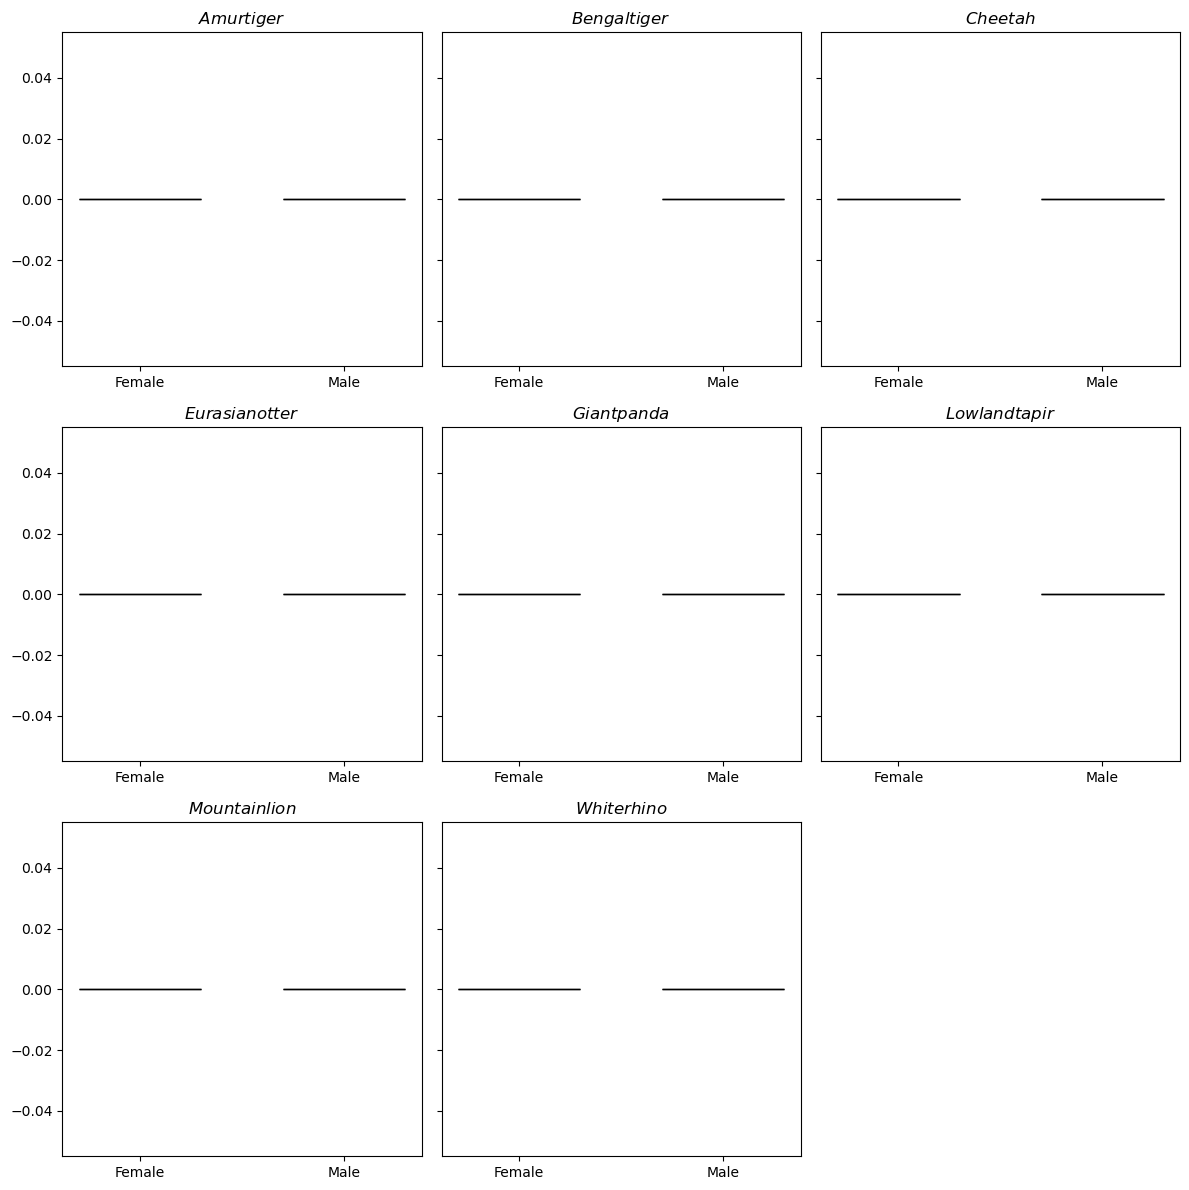

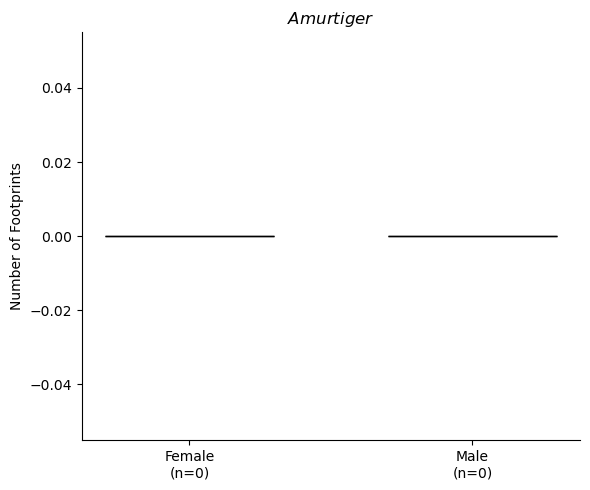

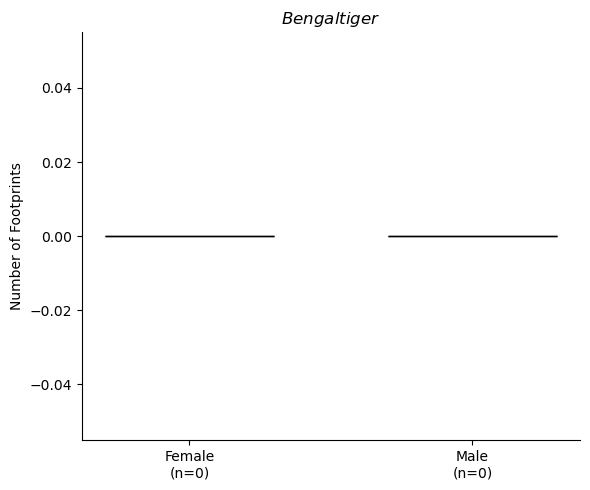

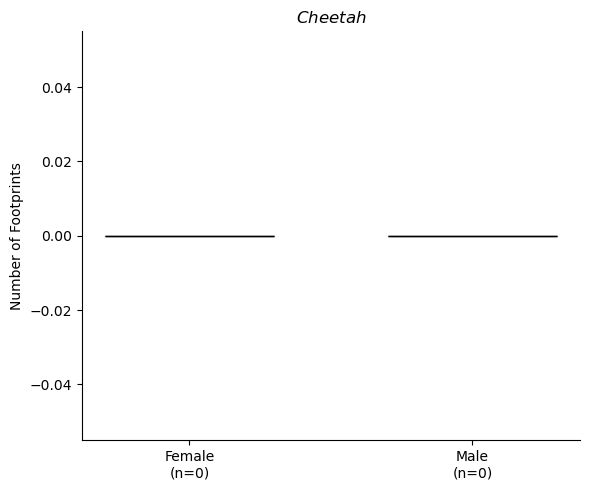

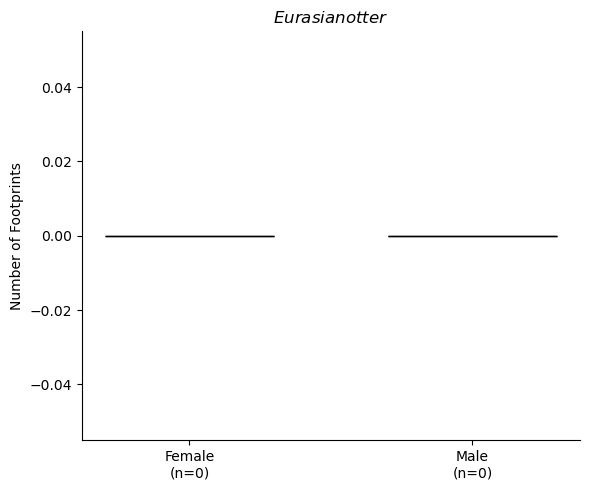

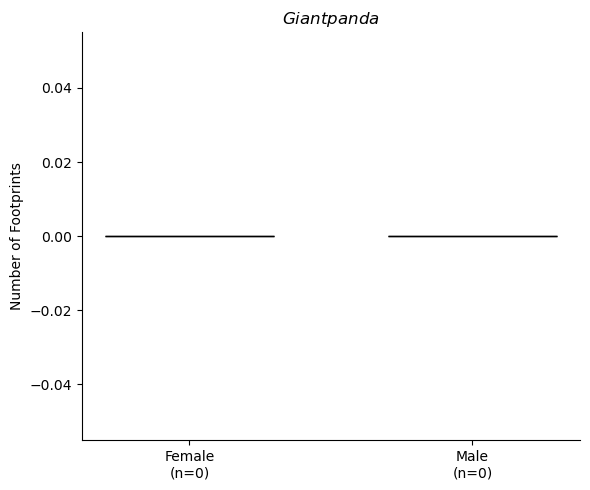

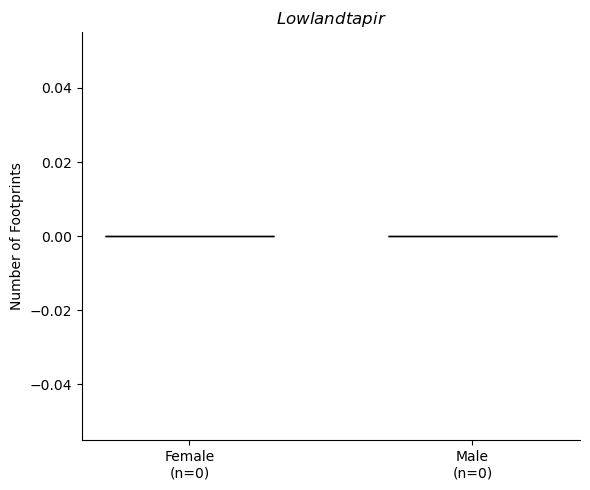

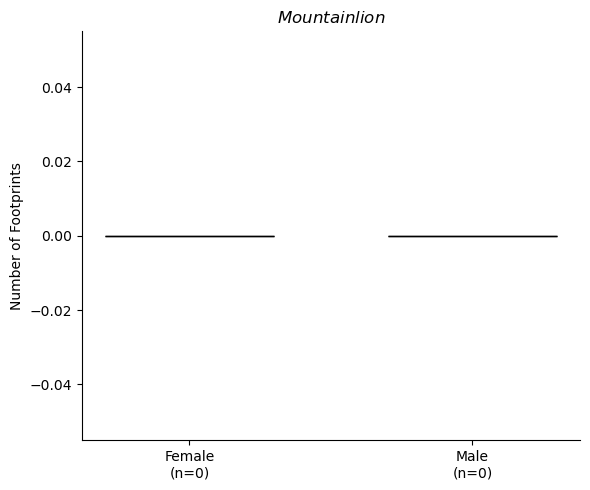

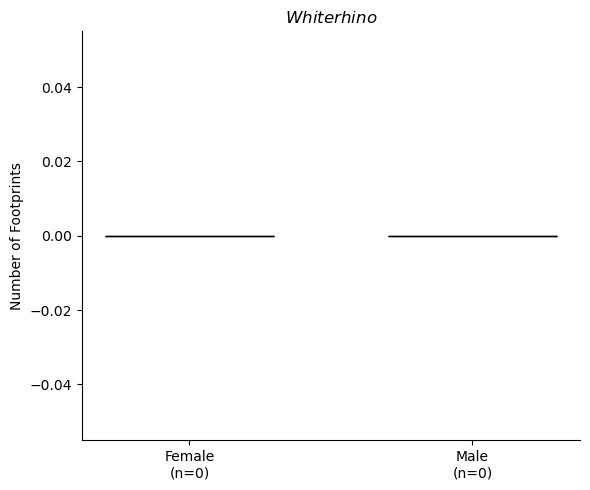

[W 2025-06-27 18:40:19,622] Trial 0 failed with parameters: {'impute_method': 'miss_forest', 'outlier_method': None, 'scaler_method': 'robust', 'reduce_pre_method': 'tsne', 'reduce_post_method': None, 'fs_method': 'univariate', 'fs_k': 58, 'model_key': 'et'} because of the following error: ValueError("method must be 'forward' or 'random_forest'").
Traceback (most recent call last):
  File "c:\Users\Frede\anaconda3\envs\FIT_python_conda_env\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Frede\AppData\Local\Temp\ipykernel_26256\1444974014.py", line 64, in objective
    df_raw = pw.run()
             ^^^^^^^^
  File "C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\pipeline\pipeline_wrapper.py", line 191, in run
    steps = get_pipeline_steps(
            ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_pyt

ValueError: method must be 'forward' or 'random_forest'

In [3]:
# %%capture
import optuna
from optuna.samplers import TPESampler
from tqdm.auto import tqdm
import pandas as pd
from FIT_python.config import RESULTS_DATA_DIR

from FIT_python.pipeline.pipeline_wrapper import PipelineWrapper

# Anzahl der Trials pro Studie
N_TRIALS = 50

# Hyperparameter-Suchraum ohne "all"
HYPERSPACE = {
    "impute_method":      [None, "miss_forest"],
    "outlier_method":     [None, "clip", "zscore"],
    "scaler_method":      [None, "standard", "robust"],
    "reduce_pre_method":  [None, "pca", "umap", "tsne"],
    "reduce_post_method": [None, "pca", "umap", "tsne"],
    # FS-Methoden: keine "all"-Option mehr
    "fs_method":          [None, "forward", "random_forest", "variance", "univariate", "lasso"],
    # 0 bedeutet “keine Selektion”, sonst uniform zwischen 1 und 200
    "fs_k":               (0, 200),
    "model_key":          ["log_reg", "rf", "et", "knn", "svm", "lda", "xgb"],
}

def make_objective(species_filter: str | None, experiment_name: str):
    def objective(trial: optuna.Trial) -> float:
        impute   = trial.suggest_categorical("impute_method",     HYPERSPACE["impute_method"])
        outlier  = trial.suggest_categorical("outlier_method",    HYPERSPACE["outlier_method"])
        scaler   = trial.suggest_categorical("scaler_method",     HYPERSPACE["scaler_method"])
        red_pre  = trial.suggest_categorical("reduce_pre_method", HYPERSPACE["reduce_pre_method"])
        red_post = trial.suggest_categorical("reduce_post_method",HYPERSPACE["reduce_post_method"])
        fs_meth  = trial.suggest_categorical("fs_method",         HYPERSPACE["fs_method"])
        # fs_k: 0→alle Features, sonst uniform 1–200
        low, high = HYPERSPACE["fs_k"]
        raw_k = trial.suggest_int("fs_k", low, high)
        fs_k = None if raw_k == 0 else raw_k
        model_k  = trial.suggest_categorical("model_key",        HYPERSPACE["model_key"])

        params = {
            "model_keys":        [model_k],
            "impute_method":     impute,
            "outlier_method":    outlier,
            "scaler_method":     scaler,
            "reduce_pre_method": red_pre,
            "reduce_post_method":red_post,
            "fs_method":         fs_meth,
            "fs_k":              fs_k,
        }

        print(f"\n▶ Trial {trial.number+1}/{N_TRIALS} [{experiment_name}] Parameter:")
        for k, v in params.items():
            print(f"   • {k:16}: {v!r}")
        print("   ⏳ Pipeline läuft …")

        pw = PipelineWrapper(**params)
        # Ergebnisse in eigenen Unterordner schreiben
        base = pw._model_dir.parent / experiment_name
        (base / "raw").mkdir(parents=True, exist_ok=True)
        (base / "best").mkdir(parents=True, exist_ok=True)
        pw.RESULTS_DATA_DIR = base  # override

        df_raw = pw.run()

        if species_filter:
            df_raw = df_raw[df_raw["species"] == species_filter]

        # Balanced Accuracy (Macro-Recall)
        df_raw["balanced_accuracy"] = df_raw["classification_report"].apply(
            lambda cr: cr["macro avg"]["recall"]
        )
        mean_bal = df_raw["balanced_accuracy"].mean()

        print(f"   ✅ Pipeline fertig → mean_balanced_accuracy = {mean_bal:.4f}")
        return mean_bal

    return objective

# Studie 1: nur lutra_lutra
TARGET = "lutra_lutra"
study_one = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
pbar_one = tqdm(total=N_TRIALS, desc=f"Trials ({TARGET})")
study_one.optimize(
    make_objective(TARGET, "lutra_lutra_only"),
    n_trials=N_TRIALS,
    callbacks=[lambda s, t: pbar_one.update(1)]
)
pbar_one.close()

# Studie 2: alle Spezies
study_all = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
pbar_all = tqdm(total=N_TRIALS, desc="Trials (ALL species)")
study_all.optimize(
    make_objective(None, "all_species"),
    n_trials=N_TRIALS,
    callbacks=[lambda s, t: pbar_all.update(1)]
)
pbar_all.close()

# Ausgabe
print(f"\n✅ LUTRA_ONLY best: value={study_one.best_value:.4f}, params={study_one.best_params}")
print(f"✅ ALL_SPECIES best: value={study_all.best_value:.4f}, params={study_all.best_params}")
